In [76]:
import h5py
import numpy as np
from collections import defaultdict
import pandas as pd
import pylab as pyl
import pywt
import pandas as pd

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm

from cea.signal2D import*
from cea.general import*
from cea.output import*
from cea.data_loader import*

In [77]:
data, labels = load_RTCEA("data/RTCEA_bimode.hdf5")
atwood = create_atwood_dic(labels)

idxs = atwood[0.3]
sim = data[idxs,::-1,:] 
time = labels[idxs,1]

In [78]:
t = sim.shape[0]-1
x2d = sim[t, :, :]                  # <-- IMAGE 2D au temps t

dim = x2d.shape[0]*x2d.shape[1]
print("Dimmensions, " + str(dim))

Dimmensions, 131072


# Comparaison des approches 1D
## Calcul
### Parametres

In [79]:
T = 0.4
iteration = 50
wavelet = "sym6"
alpha = 0.2

pACP = 90 #%
methods = [
    "Wavelets Lineaires",
    "Wavelets non Lineaires",
    "Fourier Lineaire",
    "Fourier non Lineaire",
    "ACP",
    "ACP " + str(pACP) + "%"
]
n = np.full(len(methods), int(x2d.size / 2))   # nombre de coefficients (2D)

errors = np.zeros((len(methods), iteration, 2))

### Bases d'ACP parametriques
Création de 2 bases d'ACP pour observer la capacité de generalisation de l'ACP au probleme.
- Base 100% : Créer a partir des resultat du temps complet de la simulation tel que $X = U\Sigma V^T | X=\{x_{w,l}(t) | t \in [0;t_{max}] \}$
- Base 95% : Créer a partir des resultat de 95% du temps de simulation tel que $X_{95} = U_{95}\Sigma_{95} V^T_{95} | X=\{x_{w,l}(t) | t \in [0;0.95\cdot t_{max}] \}$

In [80]:
base_acp = doACP_2d(sim)

# s = int(pACP*sim.shape[0])
# sbase_acp = doACP_2d(sim[:s,:,:]) 
rng = np.random.default_rng(seed=42)  # seed pour reproductibilité
s_idx = rng.choice(sim.shape[0], size=int((pACP/100)*sim.shape[0]), replace=False)
sbase_acp = doACP_2d(sim[s_idx,:,:])

si = np.zeros((len(methods), *x2d.shape))

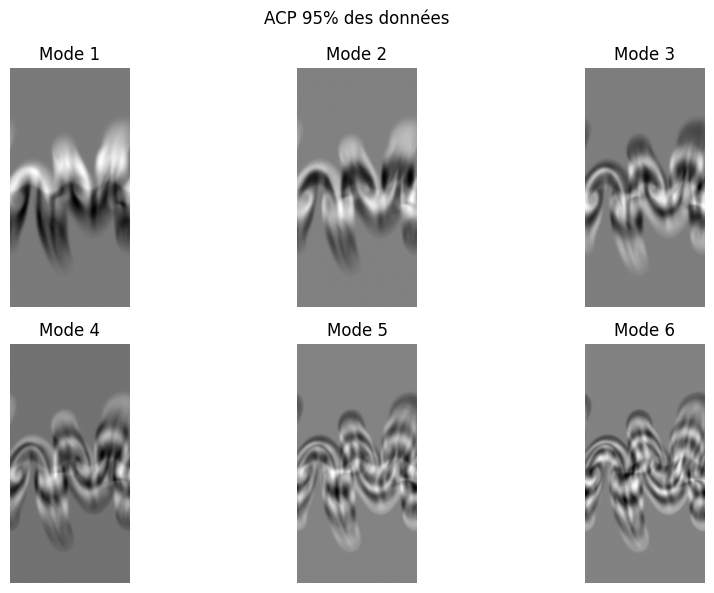

In [81]:
plot_acp_modes(sbase_acp, "ACP 95% des données")

### Boucle d'optimisation des vecteurs propres

In [82]:
for i in range(iteration):

    si[0] = wavelet_lineaire_2d(x2d, int(n[0]), wavelet)
    si[1] = wavelet_non_lineaire_2d(x2d, int(n[1]), wavelet)
    si[2] = fourier_lineaire_2d(x2d, int(n[2]))
    si[3] = fourier_non_lineaire_2d(x2d, int(n[3]))
    si[4] = acp_non_lineaire_2d(base_acp, x2d, int(n[4]))
    si[5] = acp_non_lineaire_2d(sbase_acp, x2d, int(n[5]))

    # adaptation des n
    for j in range(len(methods)):
        err = np.linalg.norm(si[j] - x2d)
        errors[j, i, 0] = n[j]
        errors[j, i, 1] = err
        
        if err < T:
            n[j] *= (1 - alpha)
        else:
            n[j] *= (1 + alpha)

        n[j] = max(1, min(x2d.size, int(n[j])))

In [83]:
print("n finaux :", n)
print("ratio (dim final/dim intiale):", np.round(n/dim, 3))

n finaux : [ 79690  10478 131072  15731     30     28]
ratio (dim final/dim intiale): [0.608 0.08  1.    0.12  0.    0.   ]


## Comparaison des différents résultats

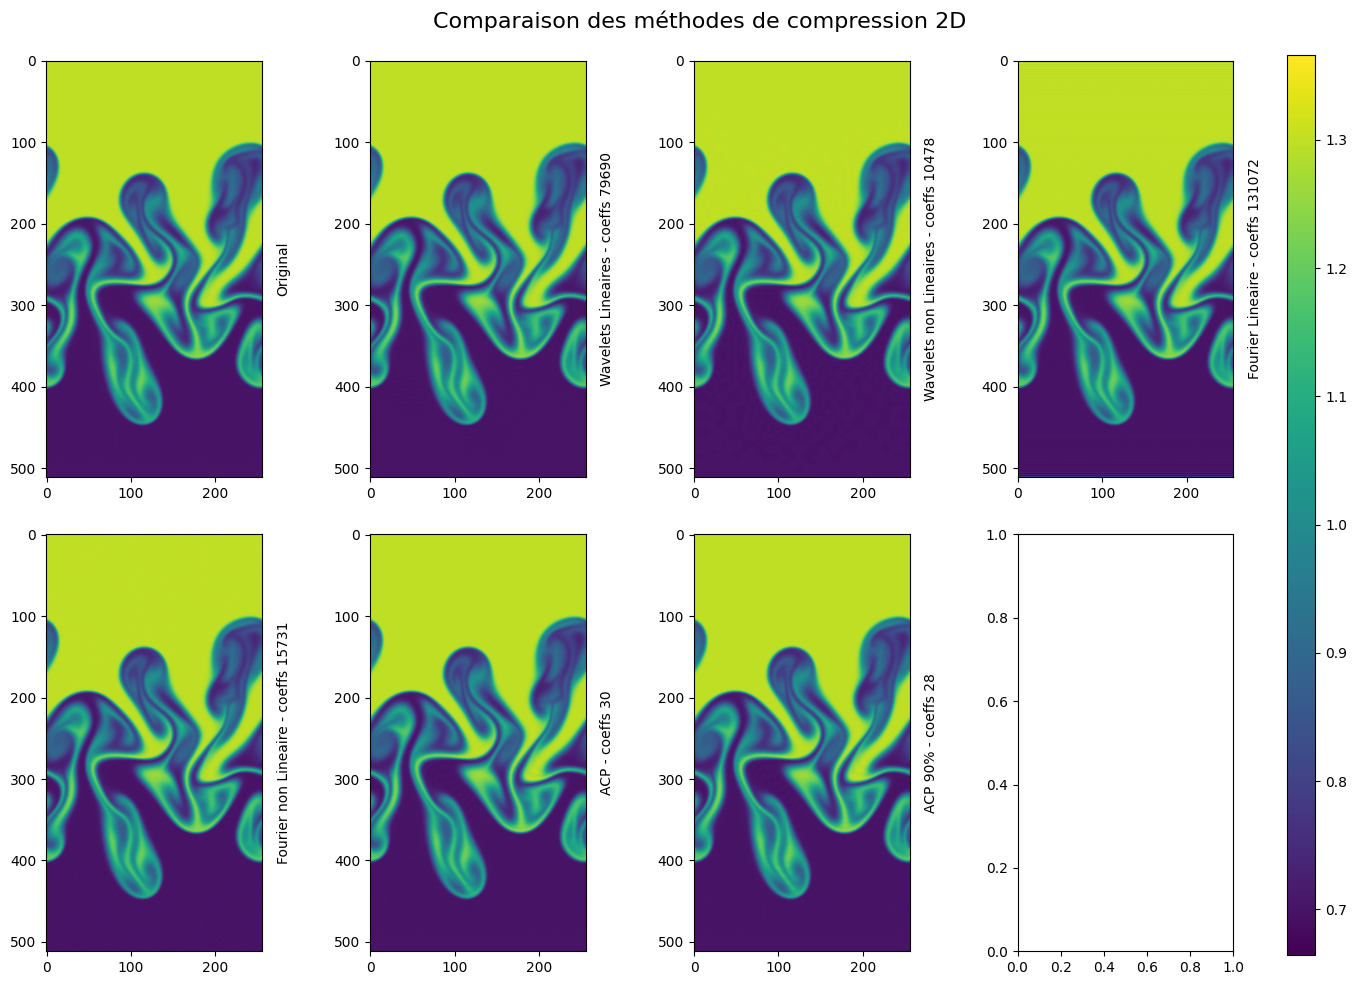

In [84]:
y_inf, y_supp = 0.95*np.min(x2d), 1.05*np.max(x2d)

fig, ax = plt.subplots(2, 4, figsize=(14, 10))
ax = ax.flatten()

fig.tight_layout(rect=[0, 0, 0.9, 0.95], h_pad=2)  # on laisse de la place à droite
fig.subplots_adjust(wspace=0.5)
fig.suptitle("Comparaison des méthodes de compression 2D", fontsize=16)

# original
im = ax[0].imshow(x2d, aspect='auto', vmin=y_inf, vmax=y_supp)
ax[0].text(1.1, 0.5, "Original", transform=ax[0].transAxes,
           va='center', ha='center', rotation=90)

# autres plots
for i in range(len(methods)):
    im = ax[i+1].imshow(si[i], aspect='auto', vmin=y_inf, vmax=y_supp)
    ax[i+1].text(
        1.1, 0.5,
        f"{methods[i]} - coeffs {n[i]}",
        transform=ax[i+1].transAxes,
        va='center',
        ha='center',
        rotation=90
    )

# axe colorbar (x, y, largeur, hauteur)
cbar_ax = fig.add_axes([0.92, 0.035, 0.02, 0.9])
fig.colorbar(im, cax=cbar_ax)

plt.show()

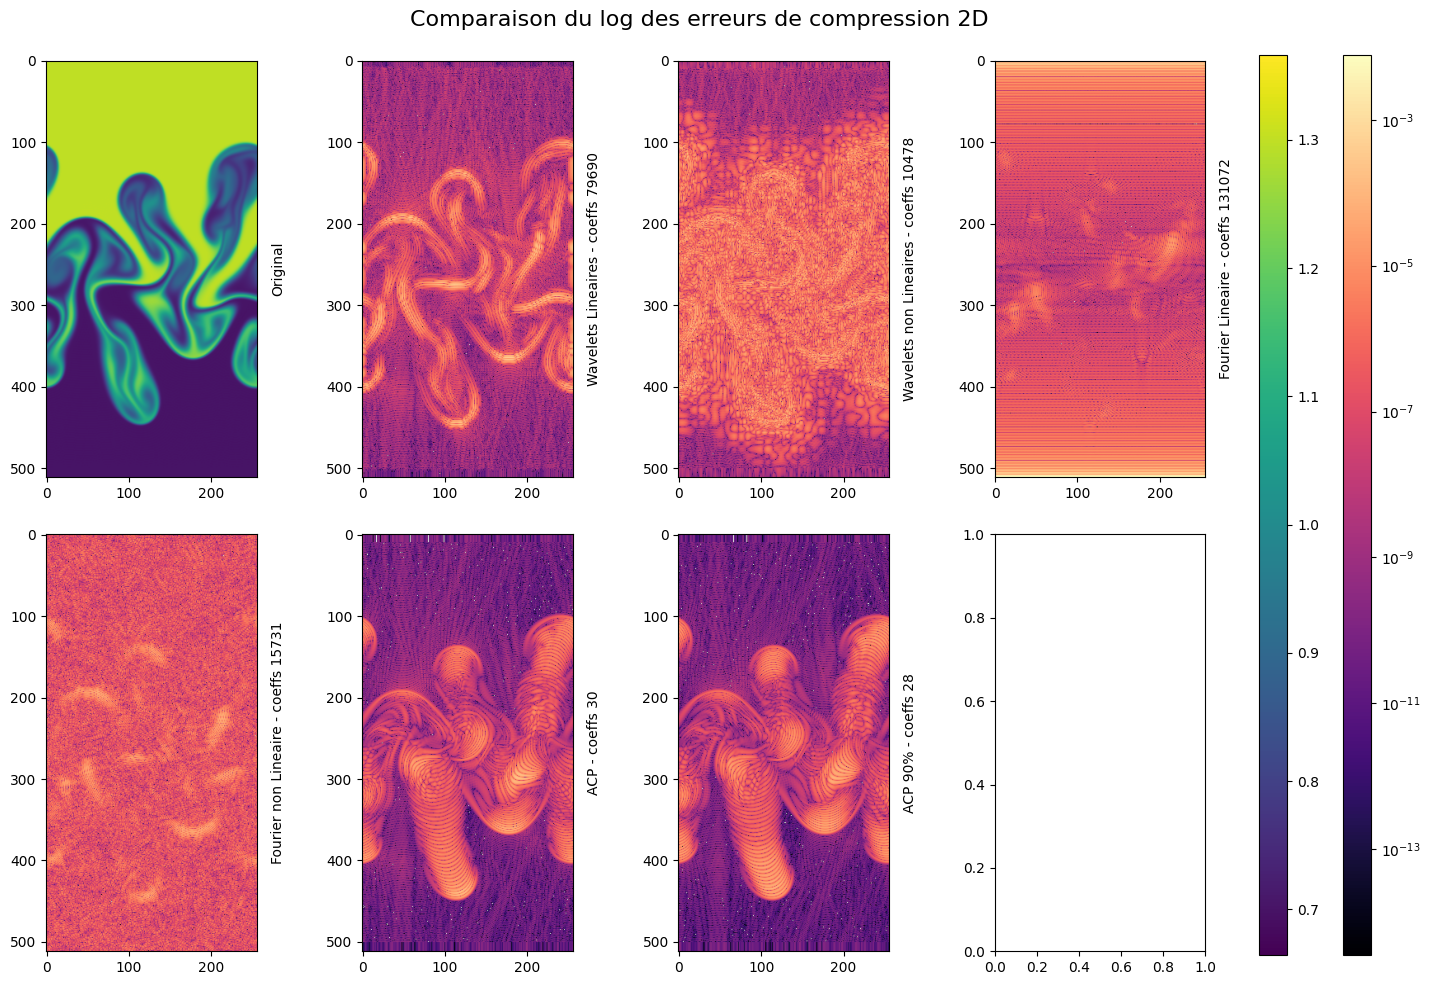

In [85]:
y_inf, y_supp = 0.95*np.min(x2d), 1.05*np.max(x2d)

fig, ax = plt.subplots(2, 4, figsize=(14, 10))
ax = ax.flatten()

fig.tight_layout(rect=[0, 0, 0.88, 0.95], h_pad=2)
fig.subplots_adjust(wspace=0.5)
fig.suptitle("Comparaison du log des erreurs de compression 2D", fontsize=16)

# ======================
# ORIGINAL (colormap 1)
# ======================
im0 = ax[0].imshow(x2d, aspect='auto', vmin=y_inf, vmax=y_supp, cmap='viridis')
ax[0].text(1.1, 0.5, "Original", transform=ax[0].transAxes,
           va='center', ha='center', rotation=90)

# ======================
# ERREURS (colormap 2)
# ======================
# erreurs (sans log !)
plt_errors = [(si[i] - x2d)**2 for i in range(len(methods))]

# éviter les zéros pour le log
err_min = min(np.min(e[e > 0]) for e in plt_errors)
err_max = max(np.max(e) for e in plt_errors)

for i in range(len(methods)):
    im_err = ax[i+1].imshow(
        plt_errors[i],
        aspect='auto',
        norm=LogNorm(vmin=err_min, vmax=err_max),
        cmap='magma'
    )
    ax[i+1].text(
        1.1, 0.5,
        f"{methods[i]} - coeffs {n[i]}",
        transform=ax[i+1].transAxes,
        va='center',
        ha='center',
        rotation=90
    )

# ======================
# COLORBARS
# ======================

# colorbar original
cbar_ax1 = fig.add_axes([0.90, 0.035, 0.02, 0.9])
fig.colorbar(im0, cax=cbar_ax1)

# colorbar erreurs (à droite de la première)
cbar_ax2 = fig.add_axes([0.96, 0.035, 0.02, 0.9])
fig.colorbar(im_err, cax=cbar_ax2)

plt.show()

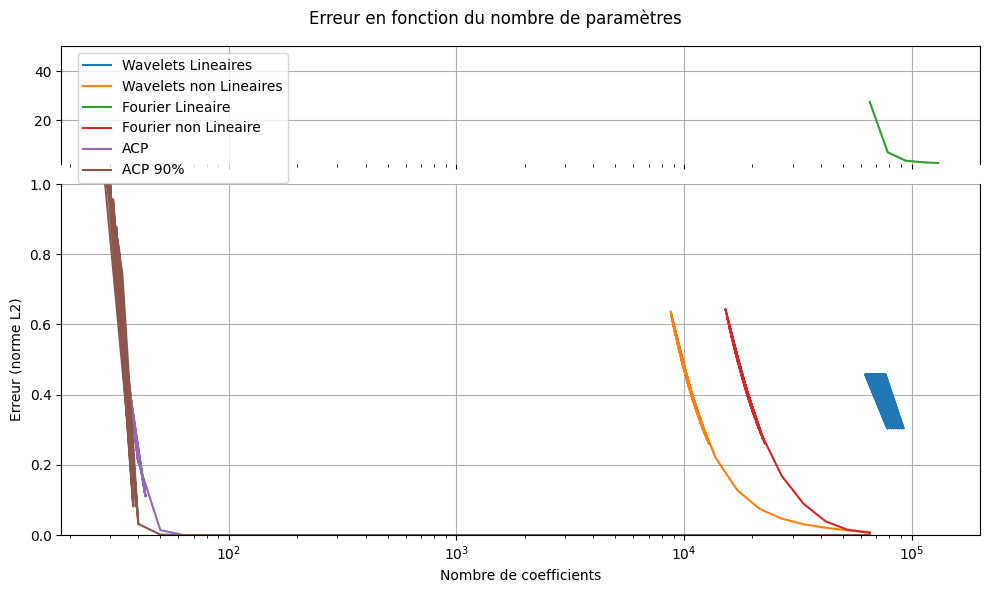

In [86]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(10, 6),
    gridspec_kw={'height_ratios': [1, 3]}
)

for j in range(len(methods)):
    ax1.plot(errors[j, :, 0], errors[j, :, 1], label=methods[j])
    ax2.plot(errors[j, :, 0], errors[j, :, 1], label=methods[j])
    # ax1.scatter(errors[j, :, 0], errors[j, :, 1],marker='x', label=methods[j])
    # ax2.scatter(errors[j, :, 0], errors[j, :, 1],marker='x', label=methods[j])

# ------ Limites des axes pour faire une cassure ------ #
ax1.set_ylim(2.5, 50)   # zone haute
ax2.set_ylim(0, 1)     # zone basse

ax1.set_xscale('log')
ax2.set_xscale('log')

# ------ Style ------- # 
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax1.tick_params(labeltop=False)
ax2.xaxis.tick_bottom()

# ------ Lables ------ #
ax2.set_xlabel("Nombre de coefficients")
# ax1.set_ylabel("Erreur (norme L2)")
ax2.set_ylabel("Erreur (norme L2)")

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(0.3, 0.8))
ax1.grid()
ax2.grid()

plt.suptitle("Erreur en fonction du nombre de paramètres")
plt.tight_layout()
plt.show()

**Remarque**

Ici on voit clairement par la troncature et les instabilités des wavelets et de la transformé de fourier linéaire que la physique n'est pas respecté pour ces operateurs.

-> Pas de conservation de l'energie, donc probleme sur la norme qui empeche de converger.

## Approfondissement sur les ondelettes 2D

### Decomposition d'un niveau
$sig(x,y) \to \{LL, LH, HL, HH\}$

| Sous-bande    | Signification | Rôle |
| -----------   | -----------   | ----------- |
| LL            | Low-Low       | Approximation de la structure generale | 
| LH            | Low-High      | Details veritcaux |
| HL            | High-Low      | Details horizontaux |
| HH            | High-High     | Details diagonaux |

Ce qui dans le code se retrouve sous forme,

> ```python
> coeffs[1][0] → LH 
> coeffs[1][1] → HL 
> coeffs[1][2] → HH 
> ```

### Mutli niveaux
$sig(x,y) \to \{LL_L, (LH_L, HL_L, HH_L),...(LH_1, HL_1, HH_1)\}$
> Noté [cAL​,(cHL​,cVL​,cDL​),...,(cH1​,cV1​,cD1​)] dans PyWavelet

Dans la figure on a donc, 
- Niveau 0 : image originale
- Niveau 1 : première séparation fréquentielle
- Niveau 2+ : structures de plus en plus globales

Pour un nombre de niveaux $L$ fini on peut donc écrire 

$ sig = \sum_{ l=1 \in L }(LH_l+HL-l+HH_l)+LL_L $

Ou commem dans la doc PyWavlet, 

$ sig = A_L+\sum_{ l=1 \in L }D_l \quad$ avec $\quad D_l = (LH_l+HL-l+HH_l)$

### References
Cette representation est inspiré de, 
- la figure 1 de [Wavelet compression of off-axis digital holograms using real/imaginary and amplitude phase parts](https://www.nature.com/articles/s41598-019-44119-0) par P. A. Cheremkhin & E. A. Kurbatova 
- la figure 9.3 du livre [A wavelet tour of signal processing](http://deadnet.se:8080/Books_and_manuals_on_various_stuff/Electronics%20and%20Communications/Electronics%20ebook%20collection%20II/MALLAT%2C%20S.%20%281999%29.%20A%20Wavelet%20Tour%20of%20Signal%20Processing%20%282nd%20ed.%29.pdf) de S.Mallat


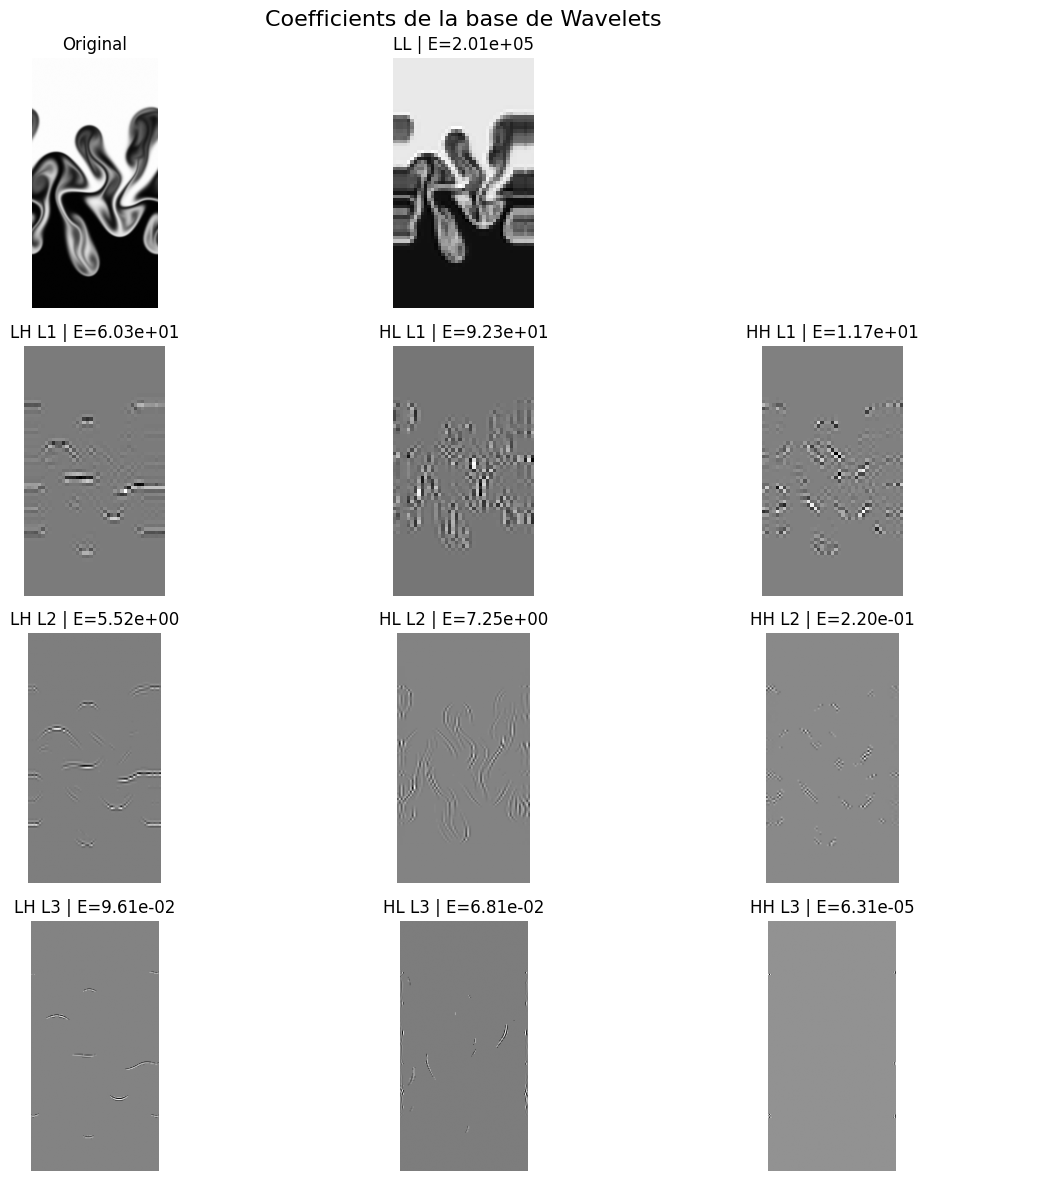

In [87]:
x_rec = wavelet_non_lineaire_2d(x2d, int(n[1]), wavelet)
plot_wavelet_custom_layout_2d(x_rec, titre="Coefficients de la base de Wavelets")

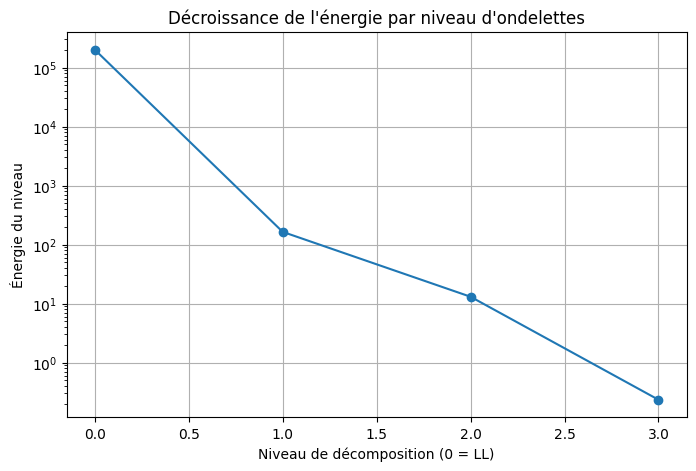

In [88]:
def wavelet_energy_by_level(x, wavelet="sym6", level=3):
    coeffs = pywt.wavedec2(x, wavelet=wavelet, level=level)

    energies = []

    def energy(c):
        return np.sum(np.square(c))

    # niveau 0 : approximation finale (LL)
    energies.append(energy(coeffs[0]))

    # niveaux de détails
    for l in range(1, len(coeffs)):
        cH, cV, cD = coeffs[l]
        E = energy(cH) + energy(cV) + energy(cD)
        energies.append(E)

    return np.array(energies)

def plot_wavelet_energy_curve(x, wavelet="sym6", level=3):
    E = wavelet_energy_by_level(x, wavelet=wavelet, level=level)

    plt.figure(figsize=(8, 5))

    levels = np.arange(len(E))

    plt.plot(levels, E, marker='o')

    plt.yscale("log")  # IMPORTANT : énergie souvent très décroissante

    plt.xlabel("Niveau de décomposition (0 = LL)")
    plt.ylabel("Énergie du niveau")
    plt.title("Décroissance de l'énergie par niveau d'ondelettes")
    plt.grid(True)

    plt.show()

plot_wavelet_energy_curve(x2d, wavelet="sym6", level=3)


---
## ECHANTILLONNAGE FIXE : erreur vs nombre de coefficients

In [89]:
n_fixed  = 1200

In [90]:
def reconstruct_2d(j, img, n_coeff):
    """Applique la méthode j avec n_coeff coefficients sur une image 2D."""
    if j == 0: return wavelet_lineaire_2d(img, int(n_coeff), wavelet)
    if j == 1: return wavelet_non_lineaire_2d(img, int(n_coeff), wavelet)
    if j == 2: return fourier_lineaire_2d(img, int(n_coeff))
    if j == 3: return fourier_non_lineaire_2d(img, int(n_coeff))
    if j == 4: return acp_non_lineaire_2d(base_acp, img, int(n_coeff))
    if j == 5: return acp_non_lineaire_2d(sbase_acp, img, int(n_coeff))

N_pixels     = x2d.size                                               # taille totale de l'image
coeff_values = np.unique(np.round(np.geomspace(1, N_pixels // 2, num=40)).astype(int))
errors_fixed = np.zeros((len(methods), len(coeff_values)))

for ci, n_coeff in enumerate(coeff_values):
    for j in range(len(methods)):
        img_rec = reconstruct_2d(j, x2d, n_coeff)
        errors_fixed[j, ci] = np.linalg.norm(img_rec - x2d)


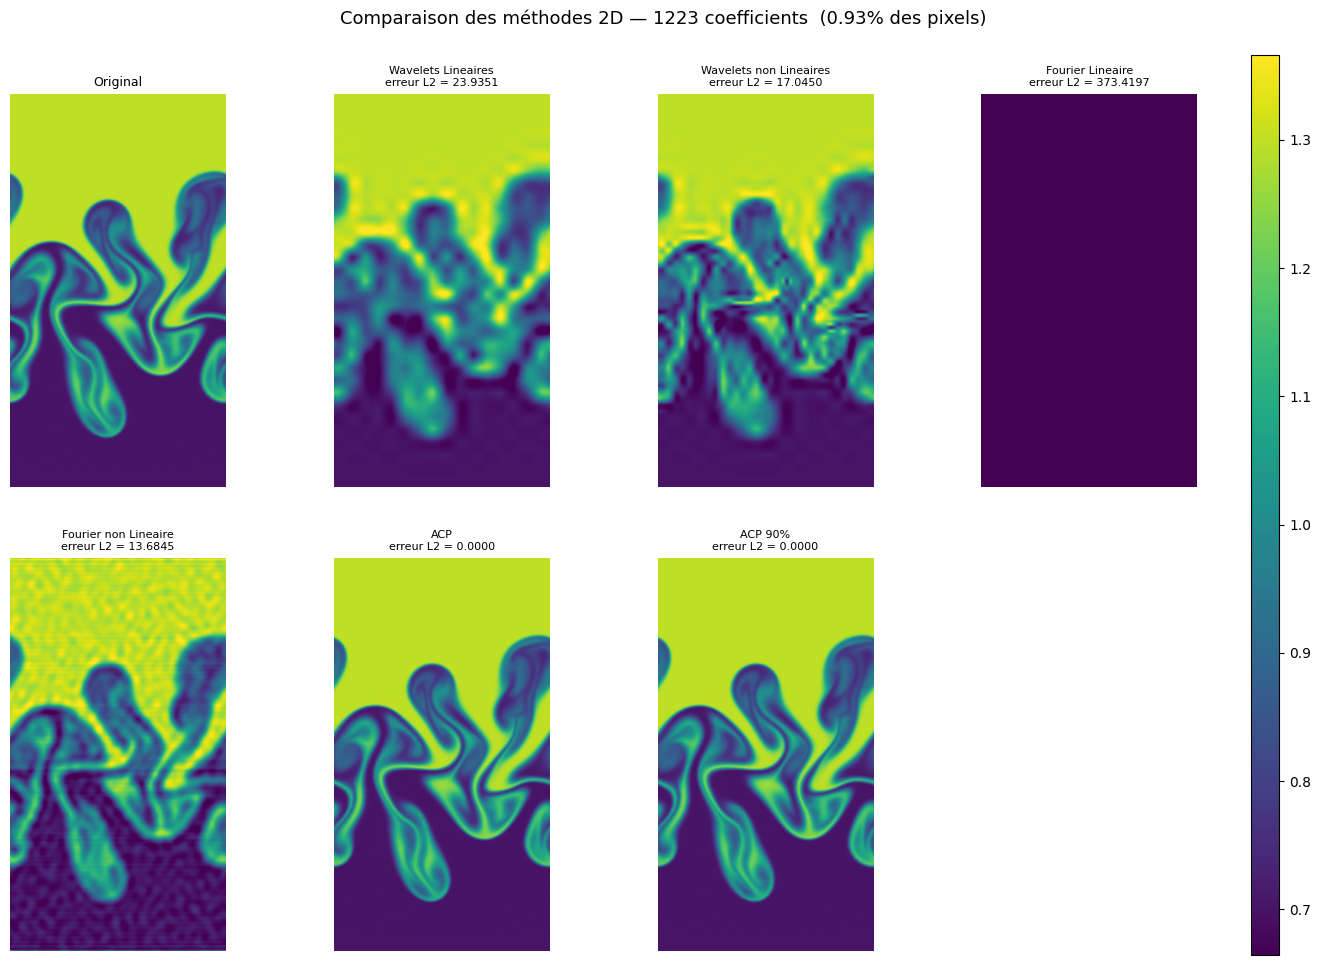

In [91]:
n_idx    = np.argmin(np.abs(coeff_values - n_fixed))
n_actual = coeff_values[n_idx]

y_inf, y_supp = 0.95 * np.min(x2d), 1.05 * np.max(x2d)

fig, ax = plt.subplots(2, 4, figsize=(14, 10))
ax = ax.flatten()
fig.suptitle(f"Comparaison des méthodes 2D — {n_actual} coefficients  ({100*n_actual/N_pixels:.2f}% des pixels)", fontsize=13)
fig.tight_layout(rect=[0, 0, 0.90, 0.95], h_pad=3)
fig.subplots_adjust(wspace=0.5)

# Original
im = ax[0].imshow(x2d, aspect='auto', vmin=y_inf, vmax=y_supp)
ax[0].set_title("Original", fontsize=9)
ax[0].axis('off')

# Reconstructions
for j in range(len(methods)):
    img_rec = reconstruct_2d(j, x2d, n_actual)
    err     = np.linalg.norm(img_rec - x2d)
    im = ax[j+1].imshow(img_rec, aspect='auto', vmin=y_inf, vmax=y_supp)
    ax[j+1].set_title(f"{methods[j]}\nerreur L2 = {err:.4f}", fontsize=8)
    ax[j+1].axis('off')

ax[7].axis('off')   # case vide en bas à droite

cbar_ax = fig.add_axes([0.92, 0.035, 0.02, 0.9])
fig.colorbar(im, cax=cbar_ax)
plt.show()


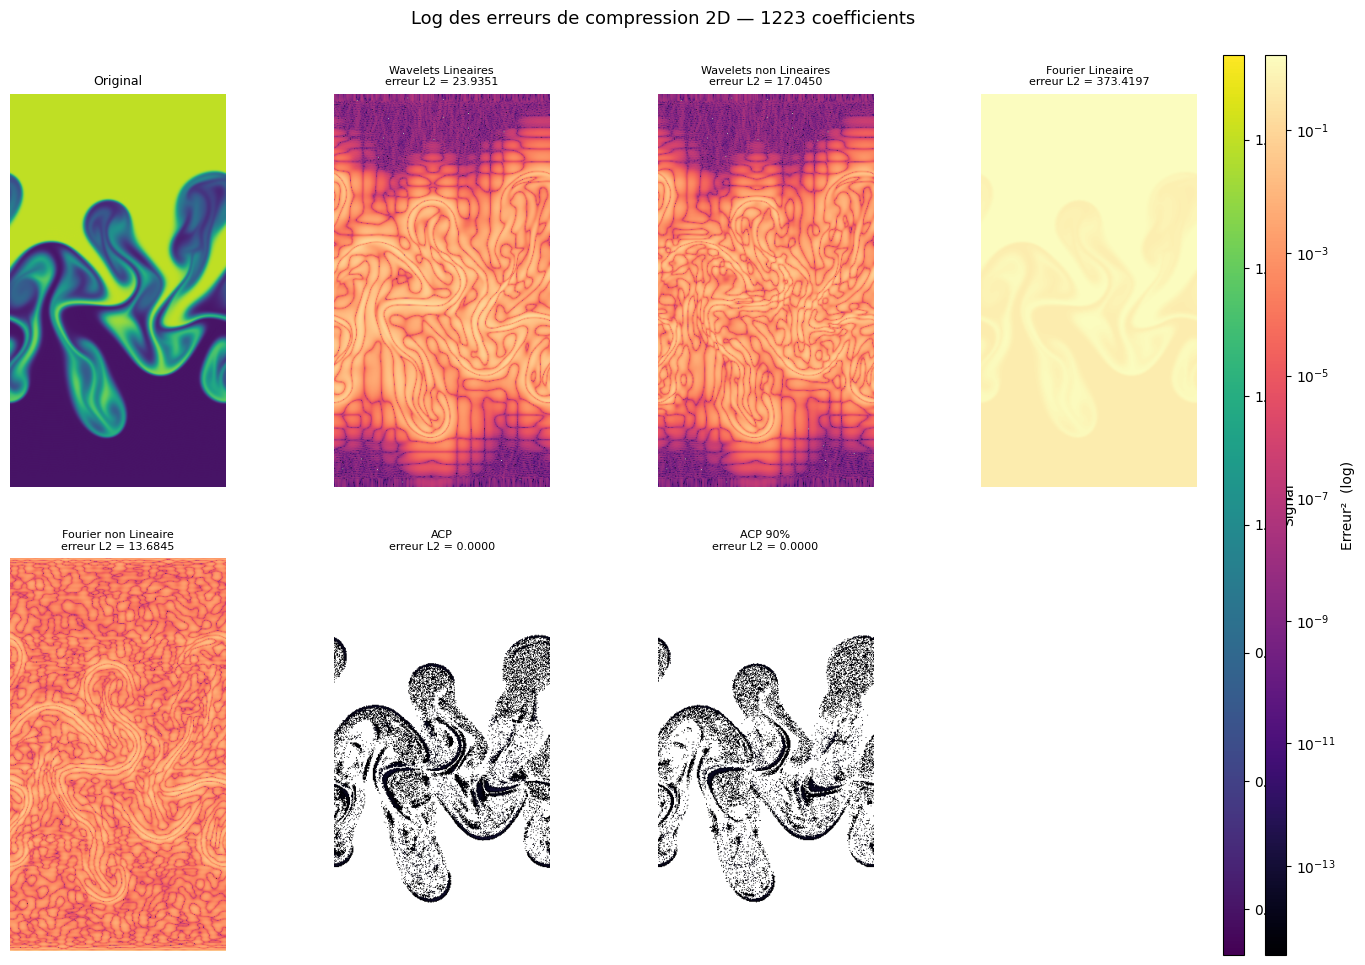

In [92]:
fig, ax = plt.subplots(2, 4, figsize=(14, 10))
ax = ax.flatten()
fig.suptitle(f"Log des erreurs de compression 2D — {n_actual} coefficients", fontsize=13)
fig.tight_layout(rect=[0, 0, 0.90, 0.95], h_pad=3)
fig.subplots_adjust(wspace=0.5)

# Original
im0 = ax[0].imshow(x2d, aspect='auto', vmin=y_inf, vmax=y_supp, cmap='viridis')
ax[0].set_title("Original", fontsize=9)
ax[0].axis('off')

# Cartes d'erreur
plt_errors = [(reconstruct_2d(j, x2d, n_actual) - x2d)**2 for j in range(len(methods))]
err_min = min(np.min(e[e > 0]) for e in plt_errors)
err_max = max(np.max(e) for e in plt_errors)

for j in range(len(methods)):
    im_err = ax[j+1].imshow(
        plt_errors[j], aspect='auto',
        norm=LogNorm(vmin=err_min, vmax=err_max), cmap='magma'
    )
    err_l2 = np.linalg.norm(np.sqrt(plt_errors[j]))
    ax[j+1].set_title(f"{methods[j]}\nerreur L2 = {err_l2:.4f}", fontsize=8)
    ax[j+1].axis('off')

ax[7].axis('off')

cbar_ax1 = fig.add_axes([0.90, 0.035, 0.015, 0.9])
fig.colorbar(im0, cax=cbar_ax1, label="Signal")

cbar_ax2 = fig.add_axes([0.93, 0.035, 0.015, 0.9])
fig.colorbar(im_err, cax=cbar_ax2, label="Erreur²  (log)")

plt.show()


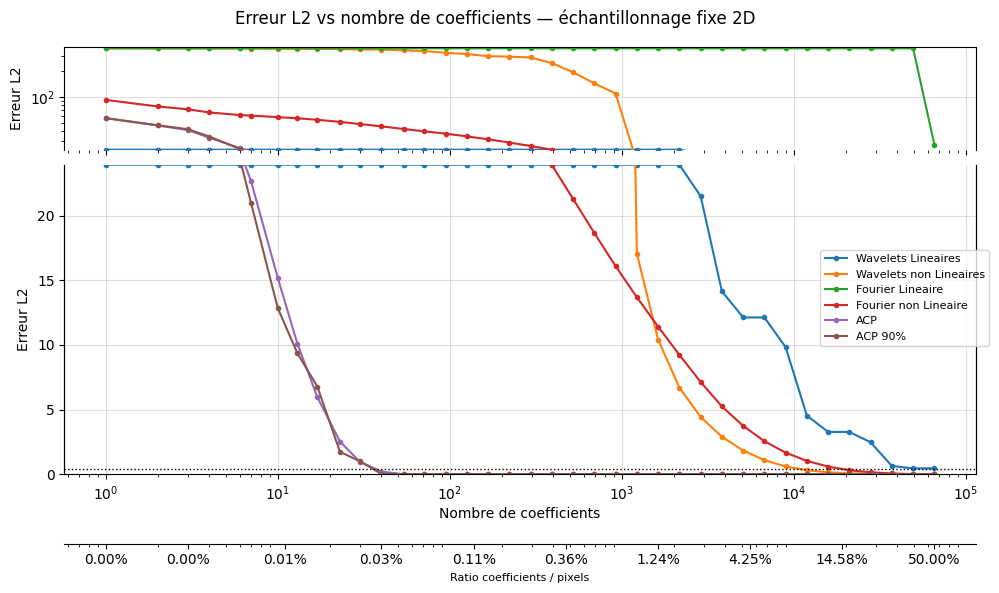

In [93]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(10, 6),
    gridspec_kw={'height_ratios': [1, 3]}
)

for j in range(len(methods)):
    ratio = coeff_values / N_pixels          # axe secondaire en % de pixels
    ax1.plot(coeff_values, errors_fixed[j], marker='o', markersize=3, label=methods[j])
    ax2.plot(coeff_values, errors_fixed[j], marker='o', markersize=3, label=methods[j])

# Seuil T
ax2.axhline(y=T, color='black', linestyle=':', linewidth=1, label=f"Seuil T={T}")

# Axe brisé
err_flat = errors_fixed[errors_fixed > 0]
ax1.set_ylim(np.percentile(err_flat, 50), np.max(err_flat) * 1.05)
ax1.set_yscale('log')
ax2.set_ylim(0, np.percentile(err_flat, 50))

ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.tick_params(labelbottom=False)
ax2.xaxis.tick_bottom()

ax1.set_xscale('log')
ax2.set_xscale('log')

# Axe secondaire (ratio) en bas
ax2b = ax2.twiny()
ax2b.spines['top'].set_visible(False)
ax2b.set_xscale('log')
ax2b.set_xlim(ax2.get_xlim())

tick_positions = np.geomspace(coeff_values[0], coeff_values[-1], num=10).astype(int)
ax2b.set_xticks(tick_positions)
ax2b.set_xticklabels([f"{100*v/N_pixels:.2f}%" for v in tick_positions], fontsize=7)
ax2b.set_xlabel("Ratio coefficients / pixels", fontsize=8)
ax2b.xaxis.set_ticks_position('bottom')
ax2b.xaxis.set_label_position('bottom')
ax2b.spines['bottom'].set_position(('outward', 50))

ax2.set_xlabel("Nombre de coefficients", labelpad=3)
ax1.set_ylabel("Erreur L2")
ax2.set_ylabel("Erreur L2")

handles, labels_leg = ax1.get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='center right', bbox_to_anchor=(1.0, 0.5), fontsize=8)

ax1.grid(True, alpha=0.4)
ax2.grid(True, alpha=0.4)
plt.suptitle("Erreur L2 vs nombre de coefficients — échantillonnage fixe 2D")
plt.tight_layout()
plt.show()